In [19]:
#Baseline Algorithms in Flat Environment
from Multi_Agent_Environment_Flat import CustomEnvironmentFlat
from pettingzoo.test import parallel_api_test
import gymnasium as gym
env = CustomEnvironmentFlat()
parallel_api_test(env, num_cycles=1_000_000)


Passed Parallel API test


In [20]:
#Random Policy
#Every agent just chooses a random action at each step
import random
import numpy as np
episode_rewards=[]
def RandomPolicy(env,input_seed):
    all_agents = ["satellite1", "satellite2", "satellite3"]
    agent_rewards = {agent: [] for agent in all_agents}
    #Initialize environment with the input seed
    obs, info = env.reset(seed=input_seed)
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    total_rewards = {agent: 0 for agent in all_agents}
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        #Choose a random sample if the agent isn't terminated or truncated
        actions = {
            agent: env.action_space(agent).sample()
            for agent in all_agents
            if not (terminated[agent] or truncated[agent])
        }
        observations, rewards, terminated, truncated, info = env.step(actions)
        #Keep track of the total rewards for eval purposes
        for agent, r in rewards.items():
            total_rewards[agent] += r
    #Because we have full observability we only need to sample the observations from 1 agent as this will be the same for each one
    satellite1_info=info['satellite1']
    Overall_Delivered_Packets=satellite1_info['Delivered_Packets']
    Overall_Excess_Energy=satellite1_info['Total_Energy_Expended']
    Overall_Number_of_Contacts_Used=satellite1_info['Total_Number_of_Contacts_Used']
    num_of_collisions=satellite1_info['Number_of_Collisions']
    total_initial_data_volume=satellite1_info['Total_Initial_Satellite_Data_Volume']
    
    agent_specific_delivered_packets=[]
    agent_specific_excess_energy=[]
    agent_specific_num_of_contacts=[]
    agent_specific_initial_data_volume=[]
    for a in all_agents:
        sat_info=info[a]
        agent_specific_delivered_packets.append(sat_info['satellite_delivered_packets'])
        agent_specific_excess_energy.append(sat_info['satellite_energy_expended'])
        agent_specific_num_of_contacts.append(sat_info['satellite_number_of_contacts_used'])
        agent_specific_initial_data_volume.append(sat_info['satellite_initial_data_volume'])
        
    env.close()
    #Return the evaluation metrics
    return total_rewards,Overall_Delivered_Packets,Overall_Excess_Energy,Overall_Number_of_Contacts_Used,agent_specific_delivered_packets,agent_specific_excess_energy,agent_specific_num_of_contacts,total_initial_data_volume,agent_specific_initial_data_volume,num_of_collisions


In [41]:
#Adaptive Sorting Heuristic
def AdaptiveSorting(env,seed):
    #We 
    init_observations,init_info=env.reset(seed=seed)
    #Next need to conduct necessary calculations to obtain the strategy for the actions
    #With full observability we can just take satellite 1's observation space as we can see everything
    #that satellite 2 and 3 can see
    sat1_init_observations=init_observations["satellite1"]
    #Need to reconstruct contact_plan in a form that is easily used rather than the current flattened version for observations
    first_150 = sat1_init_observations[:150]
    contact_plan = first_150.reshape(30, 5)
    #Need to add order identifier to each contact
    column_id=np.zeros([30,1])
    for i in range(0,30):
        column_id[i]=i
    contact_plan= np.column_stack((contact_plan, column_id))
    #Need to manage all the satellite buffers and minimize collisions
    #Dictionary that contains the remaining packets to send\
    satellite_buffers=sat1_init_observations[150:153]
    #Next need to convert this to something easily handled in the heuristic algorithm
    all_agents = ["satellite1", "satellite2", "satellite3"]
    satellite_buffers_algo=[]
    for a in range(0,3):
        satellite_buffers_algo.append(satellite_buffers[a])
    #First we are going to extract the contacts that are not padded
    real_contact_plan = contact_plan[contact_plan[:, 0] != -1]
    #print("Contact plan to be sorted")
    #print(real_contact_plan)
    sorted_contact_plan=sorted(real_contact_plan,key=lambda row: row[0])
    #print("Sorted Matrix")
    #print(sorted_contact_plan)
    #Next we need to allocate the contacts based upon the buffers of the satellites
    estimated_capacity=0
    for i in sorted_contact_plan:
        if i[0]>= 0:
            estimated_capacity+=round(i[0]*10)
    
    #Now we have our initial action strategy
    #We implement while loop here
    actions=[]#Options are 0,1,2,3
    
    for contact in sorted_contact_plan:
        #print("Current Contact")
        #print(contact)
        contact_action_options=[]
        if contact[0]<1:
            for l in range(0,3):
                contact_action_options.append(contact[2+l])
            print("Action Options")
            print(contact_action_options)
            #Next we need to check how much data is left on each satellite that can transmit
            maximum_data_remaining=0
            satellite_counter=0
            max_satellite_index=None
            for sat in satellite_buffers_algo:
                print("satellite buffer occupancy")
                print(sat)
                if sat>maximum_data_remaining:
                    max_satellite_index=satellite_counter
                    maximum_data_remaining=sat
                satellite_counter+=1
            #print("Max data remaining in a satellite buffer")
            #print(maximum_data_remaining)
            #print("Satellite buffers")
            #print(satellite_buffers_algo)
            
            #Next need to check if the maximum remaining data is still 0
            if maximum_data_remaining==0:
                actions.append([0,contact[5]])
                #print("Actions")
                #print(actions)
                #We don't want to send as no satellite that can see the ground station
                #has data to send
            else:
                #Next we will use the satellite that has the most data to send
                
                actions.append([max_satellite_index+1,contact[5]])
                print("initial planning actions")
                print(actions)
                
                #next we must update the estimated remaining data
                #Expected Number of packets sent
                print("weather")
                print(contact[0])
                print("contact length")
                print(contact[1])
                satellite_buffers_algo[max_satellite_index]=satellite_buffers_algo[max_satellite_index]-round((1-contact[0])*contact[1])
                if satellite_buffers_algo[max_satellite_index]<0:
                    satellite_buffers_algo[max_satellite_index]=0
                
                
            
            
        else:
            actions.append([0,contact[5]])
    
    #Next we need to actually implement this algorithm
    #First we need to sort the actions properly
    sorted_actions=sorted(actions,key=lambda row:row[1])
    print("Initial Sorted Actions")
    print(sorted_actions)
    #Convert the sorted_actions to a dictionary format
    true_actions={agent: 0 for agent in all_agents}
    index_counter=1
    for agent in all_agents:
        
        if sorted_actions[0]==index_counter:
            true_actions[agent]=1
        index_counter+=1    
    #Next we actions are actually implemented we check the environment and then conduct sorting and allocation
    #Again
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    
    timestep=0
    total_rewards=0
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        
        index_counter=1
        for agent in all_agents:
            if not (terminated[agent] or truncated[agent]):
                if sorted_actions[timestep][0]==index_counter:
                    true_actions[agent]=1
            index_counter+=1
        print("Actual actions")
        print(true_actions)
        observations, rewards, terminated, truncated, info = env.step(true_actions)
        for a in all_agents:
            total_rewards+=rewards[a]
        #Check if any data was sent
        sat1_init_observations=observations["satellite1"]
        new_satellite_buffers=sat1_init_observations[150:153]
        buffer_change_flag=0
        for i in range(len(satellite_buffers)):
            if satellite_buffers[i]>new_satellite_buffers[i]:
                buffer_change_flag=1
        
        #If so we need to recalculate
        satellite_buffers=new_satellite_buffers
        if buffer_change_flag==1:
            first_150 = sat1_init_observations[:150]
            contact_plan = first_150.reshape(30, 5)
            #Need to modify the contact plan to only include current observations
            updated_contact_plan=[]
            for i in range(timestep,len(contact_plan)):
                updated_contact_plan.append(contact_plan[i])
            #Need to add order identifier to each contact
            column_id=np.zeros([len(updated_contact_plan),1])
            for i in range(timestep,30):
                column_id[i-timestep]=i
            updated_contact_plan= np.column_stack((updated_contact_plan, column_id))
            #Need to manage all the satellite buffers and minimize collisions
            #Dictionary that contains the remaining packets to send
            #Next need to convert this to something easily handled in the heuristic algorithm
            all_agents = ["satellite1", "satellite2", "satellite3"]
            satellite_buffers_algo=[]
            #print(satellite_buffers)
            for a in range(0,3):
                satellite_buffers_algo.append(satellite_buffers[a])
            #Next we need to sort the contact plan by cloud cover value
            sorted_contact_plan=sorted(updated_contact_plan,key=lambda row: row[0])
            #Next we need to allocate the contacts based upon the buffers of the satellites
            estimated_capacity=0
            for i in sorted_contact_plan:
                if i[0]>= 0:
                    estimated_capacity=round(i[0]*10)            
            #Now we have our initial action strategy
            #We implement while loop here
            actions=[]#Options are 0,1,2,3
            for contact in sorted_contact_plan:
                contact_action_options=[]
                if contact[0]<1:
                    for l in range(0,3):
                        contact_action_options.append(contact[2+l])
                        #Next we need to check how much data is left on each satellite that can transmit
                        maximum_data_remaining=0
                        satellite_counter=0
                        max_satellite_index=None
                        for sat in satellite_buffers_algo:
                            if sat>maximum_data_remaining:
                                max_satellite_index=satellite_counter
                                maximum_data_remaining=sat
                            satellite_counter+=1
                        #Next need to check if the maximum remaining data is still 0
                        print
                        if maximum_data_remaining==0:
                            actions.append([0,contact[5]])
                            #We don't want to send as no satellite that can see the ground station
                            #has data to send
                        else:
                            #Next we will use the satellite that has the most data to send
                            actions.append([max_satellite_index+1,contact[5]])
                            #next we must update the estimated remaining data
                            #Expected Number of packets sent
                            satellite_buffers_algo[max_satellite_index]=satellite_buffers_algo[max_satellite_index]-round((1-contact[0])*contact[1])
                            if satellite_buffers_algo[max_satellite_index]<0:
                                satellite_buffers_algo[max_satellite_index]=0
                    else:
                        actions.append([0,contact[5]])
            
            #Next we need to actually implement this algorithm
            #First we need to sort the actions properly
            sorted_actions=sorted(actions,key=lambda row:row[1])
        timestep+=1


    #Next we export metrics from the completed episode
    satellite1_info=info['satellite1']
    Overall_Delivered_Packets=satellite1_info['Delivered_Packets']
    Overall_Excess_Energy=satellite1_info['Total_Energy_Expended']
    Overall_Number_of_Contacts_Used=satellite1_info['Total_Number_of_Contacts_Used']
    num_of_collisions=satellite1_info['Number_of_Collisions']
    total_initial_data_volume=satellite1_info['Total_Initial_Satellite_Data_Volume']
    
    agent_specific_delivered_packets=[]
    agent_specific_excess_energy=[]
    agent_specific_num_of_contacts=[]
    agent_specific_initial_data_volume=[]
    for a in all_agents:
        sat_info=info[a]
        agent_specific_delivered_packets.append(sat_info['satellite_delivered_packets'])
        agent_specific_excess_energy.append(sat_info['satellite_energy_expended'])
        agent_specific_num_of_contacts.append(sat_info['satellite_number_of_contacts_used'])
        agent_specific_initial_data_volume.append(sat_info['satellite_initial_data_volume'])
        
    env.close()
    return total_rewards,Overall_Delivered_Packets,Overall_Excess_Energy,Overall_Number_of_Contacts_Used,agent_specific_delivered_packets,agent_specific_excess_energy,agent_specific_num_of_contacts,total_initial_data_volume,agent_specific_initial_data_volume,num_of_collisions


In [42]:
#CGR
def BaselineCGR(env,seed):
    observations,info = env.reset(seed=seed)
    
    all_agents = ["satellite1", "satellite2", "satellite3"]
    
    terminated = {agent: False for agent in all_agents}
    truncated = {agent: False for agent in all_agents}
    total_rewards=0
    while not all([terminated[a] or truncated[a] for a in all_agents]):
        actions = {
            agent:1
            for agent in all_agents
            if not (terminated[agent] or truncated[agent])
        }
        observations, rewards, terminated, truncated, info = env.step(actions)
        for a in all_agents:
            total_rewards+=rewards[a]
    satellite1_info=info['satellite1']
    Overall_Delivered_Packets=satellite1_info['Delivered_Packets']
    Overall_Excess_Energy=satellite1_info['Total_Energy_Expended']
    Overall_Number_of_Contacts_Used=satellite1_info['Total_Number_of_Contacts_Used']
    num_of_collisions=satellite1_info['Number_of_Collisions']
    total_initial_data_volume=satellite1_info['Total_Initial_Satellite_Data_Volume']
    
    agent_specific_delivered_packets=[]
    agent_specific_excess_energy=[]
    agent_specific_num_of_contacts=[]
    agent_specific_initial_data_volume=[]
    for a in all_agents:
        sat_info=info[a]
        agent_specific_delivered_packets.append(sat_info['satellite_delivered_packets'])
        agent_specific_excess_energy.append(sat_info['satellite_energy_expended'])
        agent_specific_num_of_contacts.append(sat_info['satellite_number_of_contacts_used'])
        agent_specific_initial_data_volume.append(sat_info['satellite_initial_data_volume'])
        
    env.close()
    return total_rewards,Overall_Delivered_Packets,Overall_Excess_Energy,Overall_Number_of_Contacts_Used,agent_specific_delivered_packets,agent_specific_excess_energy,agent_specific_num_of_contacts,total_initial_data_volume,agent_specific_initial_data_volume,num_of_collisions


In [43]:
#Here we do the testing for each algorithm
Number_of_Episodes=100
seeds=[50,51,52,53,54]
all_agents = ["satellite1", "satellite2", "satellite3"]
CGR_reward_vector=np.zeros(len(seeds)*Number_of_Episodes)
CGR_total_delivery_ratio_vector=np.zeros(len(seeds)*Number_of_Episodes)
CGR_total_energy_expenditure_vector=np.zeros(len(seeds)*Number_of_Episodes)
CGR_total_number_of_contacts=np.zeros(len(seeds)*Number_of_Episodes)
CGR_total_number_of_collisions=np.zeros(len(seeds)*Number_of_Episodes)
CGR_mean_contact_energy_efficiency_vector=np.zeros(len(seeds)*Number_of_Episodes)
CGR_agent_delivery_ratio_vector=np.zeros([len(seeds)*Number_of_Episodes,len(all_agents)])
CGR_agent_excess_energy_vector=np.zeros([len(seeds)*Number_of_Episodes,len(all_agents)])
CGR_agent_num_of_contacts_vector=np.zeros([len(seeds)*Number_of_Episodes,len(all_agents)])

vector_index=0
for h in range(1,Number_of_Episodes):
        for b in seeds:
            total_reward,Overall_Delivered_Packets,Overall_Excess_Energy,Overall_Number_of_Contacts_Used,agent_specific_delivered_packets,agent_specific_excess_energy,agent_specific_num_of_contacts,initial_data_volume,agent_specific_data_volume,number_of_collisions=BaselineCGR(env,b)
            vector_index+=1
            #Next need to develop output metrics for analysis
            CGR_reward_vector[vector_index]=total_reward
            CGR_total_delivery_ratio_vector[vector_index]=Overall_Delivered_Packets/initial_data_volume
            CGR_mean_contact_energy_efficiency_vector[vector_index]=Overall_Delivered_Packets/Overall_Number_of_Contacts_Used
            CGR_total_number_of_collisions[vector_index]=number_of_collisions
            #print(agent_specific_delivered_packets)
            for a in range(0,len(all_agents)):
                CGR_agent_delivery_ratio_vector[vector_index,a]=agent_specific_delivered_packets[a]/agent_specific_data_volume[a]
                CGR_agent_excess_energy_vector[vector_index,a]=agent_specific_excess_energy[a]
                CGR_agent_num_of_contacts_vector[vector_index,a]=agent_specific_num_of_contacts[a]


            
Rand_reward_vector=np.zeros(len(seeds)*Number_of_Episodes)
Rand_total_delivery_ratio_vector=np.zeros(len(seeds)*Number_of_Episodes)
Rand_total_energy_expenditure_vector=np.zeros(len(seeds)*Number_of_Episodes)
Rand_total_number_of_contacts=np.zeros(len(seeds)*Number_of_Episodes)
Rand_total_number_of_collisions=np.zeros(len(seeds)*Number_of_Episodes)
Rand_mean_contact_energy_efficiency_vector=np.zeros(len(seeds)*Number_of_Episodes)
Rand_agent_delivery_ratio_vector=np.zeros([len(seeds)*Number_of_Episodes,len(all_agents)])
Rand_agent_excess_energy_vector=np.zeros([len(seeds)*Number_of_Episodes,len(all_agents)])
Rand_agent_num_of_contacts_vector=np.zeros([len(seeds)*Number_of_Episodes,len(all_agents)])

vector_index=0
for h in range(1,Number_of_Episodes):
        for b in seeds:
            total_reward,Overall_Delivered_Packets,Overall_Excess_Energy,Overall_Number_of_Contacts_Used,agent_specific_delivered_packets,agent_specific_excess_energy,agent_specific_num_of_contacts,initial_data_volume,agent_specific_data_volume,number_of_collisions=BaselineCGR(env,b)
            vector_index+=1
            #Next need to develop output metrics for analysis
            Rand_reward_vector[vector_index]=total_reward
            Rand_total_delivery_ratio_vector[vector_index]=Overall_Delivered_Packets/initial_data_volume
            Rand_mean_contact_energy_efficiency_vector[vector_index]=Overall_Delivered_Packets/Overall_Number_of_Contacts_Used
            Rand_total_number_of_collisions[vector_index]=number_of_collisions
            #print(agent_specific_delivered_packets)
            for a in range(0,len(all_agents)):
                Rand_agent_delivery_ratio_vector[vector_index,a]=agent_specific_delivered_packets[a]/agent_specific_data_volume[a]
                Rand_agent_excess_energy_vector[vector_index,a]=agent_specific_excess_energy[a]
                Rand_agent_num_of_contacts_vector[vector_index,a]=agent_specific_num_of_contacts[a]

Sort_reward_vector=np.zeros(len(seeds)*Number_of_Episodes)
Sort_total_delivery_ratio_vector=np.zeros(len(seeds)*Number_of_Episodes)
Sort_total_energy_expenditure_vector=np.zeros(len(seeds)*Number_of_Episodes)
Sort_total_number_of_contacts=np.zeros(len(seeds)*Number_of_Episodes)
Sort_total_number_of_collisions=np.zeros(len(seeds)*Number_of_Episodes)
Sort_mean_contact_energy_efficiency_vector=np.zeros(len(seeds)*Number_of_Episodes)
Sort_agent_delivery_ratio_vector=np.zeros([len(seeds)*Number_of_Episodes,len(all_agents)])
Sort_agent_excess_energy_vector=np.zeros([len(seeds)*Number_of_Episodes,len(all_agents)])
Sort_agent_num_of_contacts_vector=np.zeros([len(seeds)*Number_of_Episodes,len(all_agents)])
vector_index=0
for h in range(1,2):
        for b in seeds:
            total_reward,Overall_Delivered_Packets,Overall_Excess_Energy,Overall_Number_of_Contacts_Used,agent_specific_delivered_packets,agent_specific_excess_energy,agent_specific_num_of_contacts,initial_data_volume,agent_specific_data_volume,number_of_collisions=AdaptiveSorting(env,b)
            vector_index+=1
            Sort_reward_vector[vector_index]=total_reward
            Sort_total_delivery_ratio_vector[vector_index]=Overall_Delivered_Packets/initial_data_volume
            Sort_mean_contact_energy_efficiency_vector[vector_index]=Overall_Delivered_Packets/Overall_Number_of_Contacts_Used
            Sort_total_number_of_collisions[vector_index]=number_of_collisions
            #print(agent_specific_delivered_packets)
            for a in range(0,len(all_agents)):
                Sort_agent_delivery_ratio_vector[vector_index,a]=agent_specific_delivered_packets[a]/agent_specific_data_volume[a]
                Sort_agent_excess_energy_vector[vector_index,a]=agent_specific_excess_energy[a]
                Sort_agent_num_of_contacts_vector[vector_index,a]=agent_specific_num_of_contacts[a]


Action Options
[np.float64(0.0), np.float64(1.0), np.float64(0.0)]
satellite buffer occupancy
36.0
satellite buffer occupancy
23.0
satellite buffer occupancy
38.0
initial planning actions
[[3, np.float64(2.0)]]
weather
0.07035301625728607
contact length
10.0
Action Options
[np.float64(1.0), np.float64(0.0), np.float64(0.0)]
satellite buffer occupancy
36.0
satellite buffer occupancy
23.0
satellite buffer occupancy
29.0
initial planning actions
[[3, np.float64(2.0)], [1, np.float64(6.0)]]
weather
0.08592771738767624
contact length
10.0
Action Options
[np.float64(0.0), np.float64(0.0), np.float64(1.0)]
satellite buffer occupancy
27.0
satellite buffer occupancy
23.0
satellite buffer occupancy
29.0
initial planning actions
[[3, np.float64(2.0)], [1, np.float64(6.0)], [3, np.float64(12.0)]]
weather
0.08769936114549637
contact length
10.0
Action Options
[np.float64(0.0), np.float64(1.0), np.float64(1.0)]
satellite buffer occupancy
27.0
satellite buffer occupancy
23.0
satellite buffer occupanc

-574.7661291977834


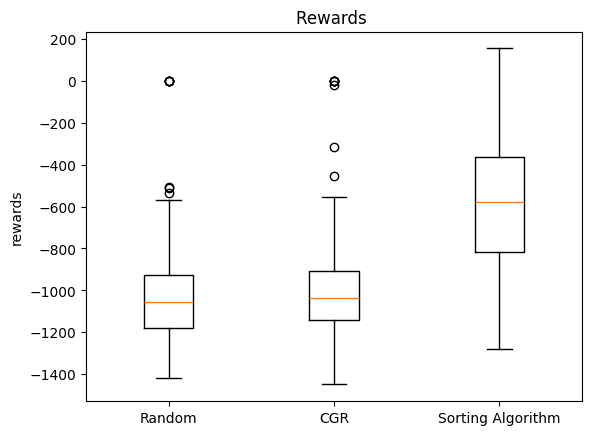

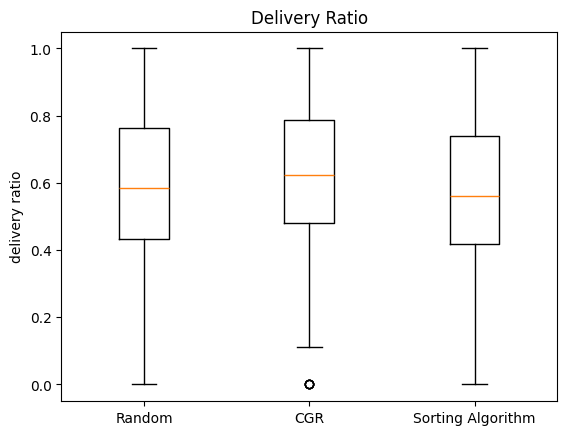

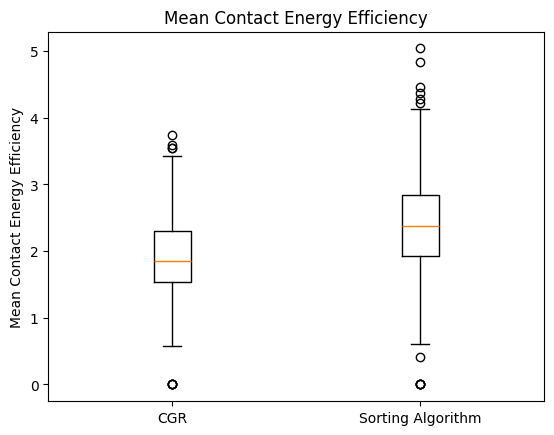

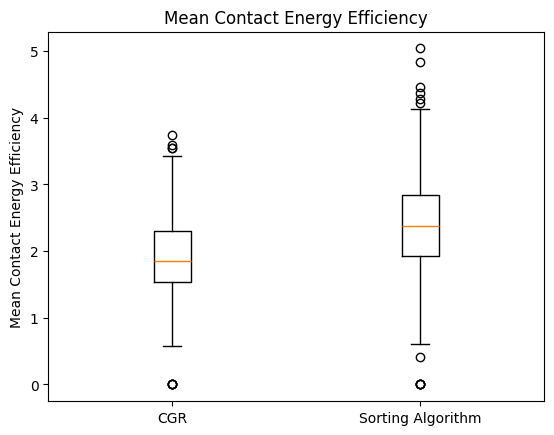

In [39]:
import matplotlib.pyplot as plt
#Reward Plot
print(np.mean(Sort_reward_vector))
plt.boxplot([Rand_reward_vector,CGR_reward_vector, Sort_reward_vector], tick_labels=['Random','CGR', 'Sorting Algorithm'])

plt.title("Rewards ")
plt.ylabel("rewards")
plt.show()

#Delivery Ratio Plot
plt.boxplot([Rand_total_delivery_ratio_vector,CGR_total_delivery_ratio_vector, Sort_total_delivery_ratio_vector], tick_labels=['Random','CGR', 'Sorting Algorithm'])

plt.title("Delivery Ratio")
plt.ylabel("delivery ratio")
plt.show()
#Contact Energy Efficiency Plot
plt.boxplot([CGR_mean_contact_energy_efficiency_vector, Sort_mean_contact_energy_efficiency_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Mean Contact Energy Efficiency")
plt.ylabel("Mean Contact Energy Efficiency")
plt.show()
plt.boxplot([CGR_mean_contact_energy_efficiency_vector, Sort_mean_contact_energy_efficiency_vector], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Mean Contact Energy Efficiency")
plt.ylabel("Mean Contact Energy Efficiency")
plt.show()

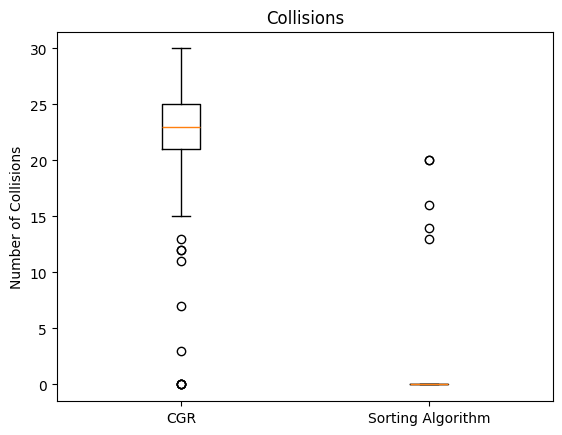

In [25]:
#Next need to produce number of collisions graphs
plt.boxplot([CGR_total_number_of_collisions, Sort_total_number_of_collisions], tick_labels=['CGR', 'Sorting Algorithm'])

plt.title("Collisions")
plt.ylabel("Number of Collisions")
plt.show()